In [1]:
import pandas as pd
import numpy as np
import os
import mo_gymnasium as mo_gym
import gymnasium as gym
from env.user_sim import UserSimEnv
import env.simulate as sim_utils
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import utils
import process_data as dp
import mp_selection 
from morld.pi_morld import PIMORLD
from pymoo.indicators.hv import HV
import pyperclip

import mdp_utils
import pymc as pm
import arviz as az
import pickle
from morld.mo_pi import MOPolicyIteration
import bayesian_analysis as ba
import arviz as az


%load_ext autoreload
%autoreload 2

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
Failed to read module file 'C:\Python311\Lib\functools.py' for module 'functools': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\shirl\Documents\Studie\2025-2026\Thesis\personalized-coping-challenges\.venv\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\shirl\Documents\Studie\2025-2026\Thesis\personalized-coping-challenges\.venv\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Python311\Lib\importlib\_

In [2]:
state_features = ['TIR', 'TIME_Q', 'MOT']
feature_names = ['Tiredness', 'Time available', 'Motivation']

action_col = "joint_cluster"

cluster_col = 'cluster_all'
cluster_vars = ['likedness', 'usefulness', 'difficulty']
cluster_cols = [col + '_cluster' for col in cluster_vars]

reward_cols = ["r_likedness", "r_usefulness", "r_diversity", "r_expert", "r_return"]
obj_names = ["Perceived Enjoyment", "Perceived Usefulness", "Diversity", "Difficulty-Weighted Adherence", "Return Willingness"]

evaluation_cols = ["likedness", "usefulness", "PAY_next", "expert_score", "diversity"]
evaluation_names = ["Perceived Enjoyment", "Perceived Usefulness", "Return Willingness", "Expert Difficulty", "Diversity"]

NUM_CATEGORIES = 4
NUM_FEATURES = len(state_features)
NUM_VALS_PER_FEATURE = [2, 2, 3]
NUM_USER_STATES = np.prod(NUM_VALS_PER_FEATURE)
NUM_CLUSTERS = 3
MAX_COUNT = 0
NUM_COUNT_STATES = (MAX_COUNT+1)**NUM_CATEGORIES
NUM_STATES = NUM_USER_STATES * NUM_COUNT_STATES 
NUM_ACTIONS = NUM_CLUSTERS * 2  # Within each cluster we either recommend a 'least favorite' coping category or a familiar one
NUM_OBJECTIVES = len(reward_cols)

### Data preparation

First we load the data and process the samples

In [ ]:
data_folder = 'C:\\Users\\shirl\\Documents\\Studie\\2025-2026\\Thesis\\personalized-coping-challenges\\data\\'
results_folder = 'C:\\Users\\shirl\\Documents\\Studie\\2025-2026\\Thesis\\personalized-coping-challenges\\results\\'

# Load data
action_data = pd.read_csv(os.path.join(data_folder, 'challenge_info.csv'))

samples = pd.read_csv(os.path.join(data_folder, 'processed_samples_adjusted_full.csv'))
agency_bias_params = (0.038, 0.013)
model_name_suffix = ""

# For optimistic adjustment
# samples = pd.read_csv(os.path.join(data_folder, 'processed_samples_adjusted_full_optimistic.csv'))
# agency_bias_params = (0.036, 0.012)
# model_name_suffix = "_optimistic_fixed"

actions_clustered, _, _ = dp.cluster_actions(action_data, cluster_vars, num_clusters=NUM_CLUSTERS)

df, agency_df, initial_distribution, mapping = dp.process_samples(samples, actions_clustered, state_features, NUM_VALS_PER_FEATURE, action_col, cluster_col, MAX_COUNT, NUM_CLUSTERS)

Number of samples after processing: 3471
Number of agency samples: 2008


In [4]:
df.groupby(['s_idx', action_col]).size().unstack(fill_value=0)

joint_cluster,0,1,2,3,4,5
s_idx,,,,,,
0,57,91,97,70,146,148
1,40,71,78,72,113,121
2,27,34,41,44,56,85
3,17,19,19,9,30,40
4,26,26,29,22,47,49
5,44,43,52,53,106,99
6,66,75,85,67,132,114
7,38,38,33,46,86,65
8,11,17,11,26,25,40


In [5]:
correlation_matrix = df[reward_cols + ['expert_score', 'completed', 'PAY_next', 'difficulty']].corr()
display(correlation_matrix)

,r_likedness,r_usefulness,r_diversity,r_expert,r_return,expert_score,completed,PAY_next,difficulty
r_likedness,1.000000,0.889139,0.000220,0.707901,0.144745,-0.133558,0.834407,0.144745,0.553116
r_usefulness,0.889139,1.000000,-0.018305,0.713782,0.186710,-0.072171,0.802463,0.186710,0.578654
r_diversity,0.000220,-0.018305,1.000000,-0.016247,0.003508,-0.051784,-0.001639,0.003508,-0.023121
r_expert,0.707901,0.713782,-0.016247,1.000000,0.101647,0.304209,0.872105,0.101647,0.633577
r_return,0.144745,0.186710,0.003508,0.101647,1.000000,0.011851,0.093820,1.000000,0.074348
expert_score,-0.133558,-0.072171,-0.051784,0.304209,0.011851,1.000000,-0.119597,0.011851,0.007206
completed,0.834407,0.802463,-0.001639,0.872105,0.093820,-0.119597,1.000000,0.093820,0.667960
PAY_next,0.144745,0.186710,0.003508,0.101647,1.000000,0.011851,0.093820,1.000000,0.074348
difficulty,0.553116,0.578654,-0.023121,0.633577,0.074348,0.007206,0.667960,0.074348,1.000000


In [6]:
completed_measures = ["Likedness", "Time Spent", "Difficulty", "Expert Usefulness", "Perceived Usefulness"]
completed_df = df[df['completed'] == 1]
completed_df = completed_df[completed_df['likedness'] != 0]

filtered_df = df[~(df['completed'] == 1 & (df['difficulty'] == 0))]

print("Total number of samples:", len(df))
print("Number of completed samples:", len(df[df['completed'] == 1]))
print("Number of filtered completed samples (no nans for completed):", len(completed_df))

completed_df_agency = agency_df[agency_df['completed'] == 1]
completed_df_agency = completed_df_agency[completed_df_agency['likedness'] != 0]

Total number of samples: 3471
Number of completed samples: 2345
Number of filtered completed samples (no nans for completed): 2325


#### Estimate transition and reward functions

In [7]:
P_comp = mdp_utils.compute_completion_probabilities(df, NUM_USER_STATES, NUM_ACTIONS, action_col, prior='action_only')
R = mdp_utils.compute_rewards(filtered_df, NUM_USER_STATES, NUM_COUNT_STATES, NUM_ACTIONS, NUM_OBJECTIVES, reward_cols, action_col, mapping)
P = mdp_utils.compute_transition_probabilities(df, NUM_USER_STATES, NUM_ACTIONS, action_col)
P_return = mdp_utils.compute_return_probabilities(df)

print("P shape:", P.shape)  # Should be (nU, nA, nU)
print("R shape:", R.shape)  # Should be (nU, nC, nA, nO)
print("P_return shape:", P_return.shape)  # Should be (nU,)

# Estimate transition and completion probabilities for agency condition for user choice simulation
P_comp_agency = mdp_utils.compute_completion_probabilities(agency_df, NUM_USER_STATES, NUM_ACTIONS, action_col, prior='action_only')
P_agency = mdp_utils.compute_transition_probabilities(agency_df, NUM_USER_STATES, NUM_ACTIONS, action_col)

completion_rates_agency = agency_df.groupby('challenge_id')['completed'].mean()
actions_clustered['completion_rate_agency'] = actions_clustered['challenge_id'].map(completion_rates_agency)

P_comp_agency

P shape: (12, 6, 12)
R shape: (12, 1, 6, 5)
P_return shape: (12,)


array([[0.53662168, 0.82941813, 0.68313953, 0.5387282 , 0.72158824,
        0.54056089],
       [0.67398299, 0.90262216, 0.69097222, 0.36121166, 0.8343074 ,
        0.59631643],
       [0.63427948, 0.87460784, 0.71226415, 0.63167587, 0.81351433,
        0.59017713],
       [0.71761281, 0.74157475, 0.675     , 0.24585635, 0.7272549 ,
        0.60144928],
       [0.69194125, 0.99518557, 0.71      , 0.31592165, 0.60794118,
        0.60110421],
       [0.63527625, 0.84489557, 0.75543478, 0.55939227, 0.58721781,
        0.81244672],
       [0.55021834, 0.84442559, 0.83482143, 0.43864055, 0.70612859,
        0.55175983],
       [0.77409025, 0.80982208, 0.89880952, 0.69834254, 0.70648739,
        0.77646025],
       [0.51590767, 0.98876634, 0.79545455, 0.89502762, 0.79544118,
        0.64573269],
       [0.43522562, 0.92434641, 0.82692308, 0.24751381, 0.65150327,
        0.51759834],
       [0.65876482, 0.84751401, 0.9375    , 0.29502762, 0.76261438,
        0.72463768],
       [0.61509669, 0

For our simulations, we use reward distributions. 

In [8]:
# df = df.merge(actions_clustered[['challenge_id'] + cluster_cols + ['time_spent_cluster']], on='challenge_id', how='left')
lam = 1  # Laplace smoothing

R_probs_fun = mdp_utils.compute_reward_probabilities(completed_df, 'likedness', NUM_USER_STATES, NUM_ACTIONS, action_col, lam=lam)
R_probs_pu = mdp_utils.compute_reward_probabilities(completed_df, 'usefulness', NUM_USER_STATES, NUM_ACTIONS, action_col, lam=lam)
R_probs_return = mdp_utils.compute_reward_probabilities(df, 'PAY_next', NUM_USER_STATES, NUM_ACTIONS, action_col, lam=lam)

R_probs = {'likedness': R_probs_fun, 'usefulness': R_probs_pu, 'PAY_next': R_probs_return}

R_probs_fun_agency = mdp_utils.compute_reward_probabilities(completed_df_agency, 'likedness', NUM_USER_STATES, NUM_ACTIONS, action_col, lam=lam)
R_probs_pu_agency = mdp_utils.compute_reward_probabilities(completed_df_agency, 'usefulness', NUM_USER_STATES, NUM_ACTIONS, action_col, lam=lam)
R_probs_return_agency = mdp_utils.compute_reward_probabilities(agency_df, 'PAY_next', NUM_USER_STATES, NUM_ACTIONS, action_col, lam=lam)

R_probs_agency = {'likedness': R_probs_fun_agency, 'usefulness': R_probs_pu_agency, 'PAY_next': R_probs_return_agency}



We need some information on the challenges for our simulation environment

In [9]:
action_categories = actions_clustered['category_id'].values  # cluster ID for each action (is same as action number if actions are clusters)
challenges_per_cluster = [[i for i in range(len(actions_clustered)) if actions_clustered[cluster_col].iloc[i] == cluster_id] for cluster_id in range(NUM_CLUSTERS)]

challenge_info = actions_clustered.set_index('challenge_id').to_dict('records')

expert_score_cols = ['score_acceptance', 'score_distraction', 'score_problem_solving', 'score_social_support']
expert_score_matrix = actions_clustered['expert_score'].values

In [10]:
env = mo_gym.make('user_env', num_actions=NUM_ACTIONS, 
                 num_objectives = NUM_OBJECTIVES, 
                 num_vals_per_feature=NUM_VALS_PER_FEATURE,
                 challenge_info=challenge_info, 
                 expert_ratings=expert_score_matrix,
                 challenges_per_cluster=challenges_per_cluster,
                 num_clusters=4,
                 transition_probs=P, 
                 completion_probs=P_comp,
                 reward_matrix=R, 
                 reward_probs=R_probs,
                 action_categories=action_categories,
                 initial_distribution=initial_distribution,
                 max_count=MAX_COUNT,
                 mapping=mapping,
                 P_comp_agency=P_comp_agency,
                 agency_bias_params=agency_bias_params)

### Setup Policy Iteration MORL/D algorithm

In [ ]:
pop_size = 128
weights_init = "combined"
scalarization = "linear"
max_eval_iters = 1000
num_iterations = 5
gamma = 0.7
ref_point = np.array([0.5, 0.5, 0.5, 0.5, 0.5])  # Reference point for Chebyshev scalarization

model_name = f'pimorld_P={pop_size}_gamma={gamma}_MOT_binary{model_name_suffix}'
filename = model_name
model_file = os.path.join(results_folder, model_name, filename)

# Initialize the PIMORLD algorithm
pi_morld = PIMORLD(env.unwrapped,
                   pop_size=pop_size, 
                   gamma=gamma,
                   max_eval_iters=max_eval_iters,
                   weights_init=weights_init,
                   scalarization=scalarization,
                   ref_point=ref_point)

# Train the model
pi_morld.train(num_iterations=1000, max_resets=30)

Initial weights for agents:
[[0.         0.         0.         0.         1.        ]
 [0.         0.         0.         0.20348524 0.79651476]
 [0.         0.         0.         0.40281049 0.59718951]
 [0.         0.         0.         0.60108623 0.39891377]
 [0.         0.         0.         0.79960042 0.20039958]
 [0.         0.         0.         1.         0.        ]
 [0.         0.         0.25916169 0.50793705 0.23290126]
 [0.         0.         0.25991581 0.         0.74008419]
 [0.         0.         0.26397129 0.25308243 0.48294628]
 [0.         0.         0.49094124 0.50905876 0.        ]
 [0.         0.         0.49559295 0.25665379 0.24775326]
 [0.         0.         0.50599475 0.         0.49400525]
 [0.         0.         0.74025807 0.25974193 0.        ]
 [0.         0.         0.74849568 0.         0.25150432]
 [0.         0.         1.         0.         0.        ]
 [0.         0.2487372  0.49492772 0.         0.25633508]
 [0.         0.25373475 0.24844609 0.       

In [12]:
save_path = os.path.join(results_folder, model_name, 'model')
save_file = "pimorld_trained.pkl"
save_to = os.path.join(save_path, save_file)
if not os.path.exists(save_path):
    os.makedirs(save_path)

with open(save_to, 'wb') as f:
    pickle.dump(pi_morld, f)

Inspect the discovered approximation set

In [13]:
print("Hypervolume of Pareto Archive: ", pi_morld.get_hv())
print("Number of solutions in Pareto Archive: ", len(pi_morld.pareto_archive.evaluations))
mp_selection.get_max_unique_actions(pi_morld.pareto_archive.individuals, NUM_STATES)

Hypervolume of Pareto Archive:  36.91597033613558
Number of solutions in Pareto Archive:  277


{'max_unique_actions': 6, 'avg_unique_actions': 4.5, 'most_disputed_state': 1}

#### Obtain subset from Pareto archive

In [14]:
rng = np.random.default_rng(66)
weight_samples = rng.dirichlet(np.ones(NUM_OBJECTIVES), size=10000)

policy_evals = np.array(pi_morld.pareto_archive.evaluations)
eum = mp_selection.calculate_expected_utility(policy_evals, weight_samples)
print("Expected Utility of Pareto Archive: ", eum)

selected_indices = mp_selection.select_policies(pi_morld.pareto_archive.individuals, policy_evals, mp_selection.score_eum, max_actions=3, weight_samples=weight_samples)
print(f"Best subset of policies has EUM: {mp_selection.calculate_expected_utility(policy_evals[selected_indices], weight_samples)}")
print("Selected policies indices: ", selected_indices)
top_n_individuals = np.array(pi_morld.pareto_archive.individuals)[selected_indices]
top_n_evaluations = np.array(pi_morld.pareto_archive.evaluations)[selected_indices]
selected_policies = np.array([ind['policy'] for ind in top_n_individuals])

policy_morl_raw = mp_selection.get_actions_per_state(top_n_individuals, NUM_STATES)

# policy_morl = [
#     {joint_cluster_to_action[action] for action in policy_morl_raw[state]}
#     for state in range(NUM_STATES)
# ]

display(policy_morl_raw)

selected_indices_expert = mp_selection.select_policies(pi_morld.pareto_archive.individuals, policy_evals, mp_selection.score_weighted_sum, max_actions=3, weights=[0, 0, 1, 1, 1])
print(f"Best subset of policies based on expert objectives has EUM: {mp_selection.calculate_expected_utility(policy_evals[selected_indices_expert], weight_samples)}")
print("Selected policies indices with expert objectives: ", selected_indices_expert)
selected_policies_expert = np.array([ind['policy'] for ind in np.array(pi_morld.pareto_archive.individuals)[selected_indices_expert]])
selected_evaluations_expert = np.array(pi_morld.pareto_archive.evaluations)[selected_indices_expert]

Expected Utility of Pareto Archive:  2.0473510152242476
Best subset of policies has EUM: 2.0457702358985674
Selected policies indices:  [49, 69, 42, 26, 45, 8, 21, 12, 11, 167, 165, 5, 29, 234, 34, 192, 24, 57, 160, 156, 176, 41, 178, 47, 10, 211, 56, 266, 130, 89, 18, 60, 9, 158, 22, 17, 28, 117, 183, 162, 37, 168, 202, 61, 27, 35, 257, 63, 72, 179, 132, 276, 180, 40, 123, 91, 85, 239, 268, 169, 125, 143, 55, 177, 44, 51, 174, 52, 212, 53, 119, 242, 186, 93, 273, 70, 260, 243, 215, 135, 175, 147, 238, 181, 172, 79, 190, 184]


{0: {np.int8(1), np.int8(4), np.int8(5)},
 1: {np.int8(2), np.int8(4), np.int8(5)},
 2: {np.int8(2), np.int8(5)},
 3: {np.int8(1), np.int8(4), np.int8(5)},
 4: {np.int8(1), np.int8(4), np.int8(5)},
 5: {np.int8(4), np.int8(5)},
 6: {np.int8(1), np.int8(4), np.int8(5)},
 7: {np.int8(3), np.int8(4)},
 8: {np.int8(1), np.int8(4), np.int8(5)},
 9: {np.int8(3), np.int8(4), np.int8(5)},
 10: {np.int8(2), np.int8(3), np.int8(5)},
 11: {np.int8(1), np.int8(3), np.int8(4)}}

Best subset of policies based on expert objectives has EUM: 2.0392089370426203
Selected policies indices with expert objectives:  [7, 5, 42, 76, 10, 22, 56, 83, 215, 11, 57, 41, 174, 257, 186, 18, 192, 123, 28, 17, 44, 60, 49, 8, 55, 260, 210, 72, 29, 63, 12, 117, 102, 9, 26, 119, 122, 6, 24, 166, 87, 161, 95, 53, 231, 201, 27, 182, 197, 133, 125, 189, 156, 150, 255, 61, 200, 152, 272, 89, 264, 240, 144, 104, 154, 146, 145, 262, 226, 207, 80, 105, 153, 205, 224, 136, 140, 65, 204, 237, 46, 106, 115, 109]


In [15]:
best_expert_idx = np.argmax(np.sum(policy_evals[:, 2:], axis=1)) 
best_expert_policy = pi_morld.pareto_archive.individuals[best_expert_idx]['policy']
print("Best expert-driven policy index: ", best_expert_idx)
print("Best expert-driven policy evaluation: ", policy_evals[best_expert_idx])
print(best_expert_policy)

Best expert-driven policy index:  7
Best expert-driven policy evaluation:  [1.38087884 1.28099417 3.33333282 1.86947326 1.98457468]
[5 3 5 5 5 5 5 3 5 3 3 3]


#### Obtain baseline policies

In [16]:
# Equal weights for all objectives
equal_weights = np.ones(NUM_OBJECTIVES) / NUM_OBJECTIVES
solver_equal = MOPolicyIteration(P, R, P_comp, equal_weights, gamma=gamma, scalarization=scalarization, max_count=MAX_COUNT, action_to_cluster=action_categories)
solver_equal.train()
if pi_morld.is_in_pareto_archive(solver_equal):
    print("Equal weights policy is in the Pareto archive.")
policy_equal = solver_equal.policy_table

# Weights based on correlations with completion
correlations = df[reward_cols + ['completed']].corr()['completed'][:-1]
weights_correlations = np.array(correlations) / np.sum(correlations)
print("Weights based on correlations: ", weights_correlations)
solver_corr = MOPolicyIteration(P, R, P_comp, weights_correlations, gamma=gamma, scalarization=scalarization, max_count=MAX_COUNT, action_to_cluster=action_categories)
solver_corr.train()
if pi_morld.is_in_pareto_archive(solver_corr):
    print("Correlation-based policy is in the Pareto archive.")
policy_corr = solver_corr.policy_table

print(policy_equal)
print(policy_corr)

Equal weights policy is in the Pareto archive.
Weights based on correlations:  [ 0.32078329  0.30850246 -0.00063014  0.33527597  0.03606842]
Correlation-based policy is in the Pareto archive.
[4 4 5 5 4 5 5 4 5 5 5 3]
[1 2 5 1 1 5 1 4 1 5 2 3]


In [17]:
joint_cluster_to_action = {
        0: ("D", 0),
        1: ("EU", 0),
        2: ("EUD", 0),
        3: ("D", 1),
        4: ("EU", 1),
        5: ("EUD", 1),
    }
def format_action(a):
    cluster, strategy = joint_cluster_to_action[a]
    return f"({cluster},{strategy})"

def format_action_set(actions):
    return r"\{" + ", ".join(format_action(a) for a in actions) + r"\}"

policy_df = pd.DataFrame({
    "State": [f"{utils.idx_to_user_state(i, NUM_VALS_PER_FEATURE)}" for i in range(NUM_STATES)],
    "MORL-UC": [format_action_set(policy_morl_raw[i]) for i in range(NUM_STATES)],
    "MORL-EP": [format_action(best_expert_policy[i]) for i in range(NUM_STATES)],
    "B-Corr": [format_action(policy_corr[i]) for i in range(NUM_STATES)],
    "B-Eq": [format_action(policy_equal[i]) for i in range(NUM_STATES)],
})

latex = policy_df.to_latex(index=False, escape=False)
pyperclip.copy(latex)

policy_df

,State,MORL-UC,MORL-EP,B-Corr,B-Eq
0,"(0, 0, 0)","\{(EU,0), (EU,1), (EUD,1)\}","(EUD,1)","(EU,0)","(EU,1)"
1,"(0, 0, 1)","\{(EUD,0), (EU,1), (EUD,1)\}","(D,1)","(EUD,0)","(EU,1)"
2,"(0, 0, 2)","\{(EUD,0), (EUD,1)\}","(EUD,1)","(EUD,1)","(EUD,1)"
3,"(0, 1, 0)","\{(EU,0), (EU,1), (EUD,1)\}","(EUD,1)","(EU,0)","(EUD,1)"
4,"(0, 1, 1)","\{(EU,0), (EU,1), (EUD,1)\}","(EUD,1)","(EU,0)","(EU,1)"
5,"(0, 1, 2)","\{(EU,1), (EUD,1)\}","(EUD,1)","(EUD,1)","(EUD,1)"
6,"(1, 0, 0)","\{(EU,0), (EU,1), (EUD,1)\}","(EUD,1)","(EU,0)","(EUD,1)"
7,"(1, 0, 1)","\{(D,1), (EU,1)\}","(D,1)","(EU,1)","(EU,1)"
8,"(1, 0, 2)","\{(EU,0), (EU,1), (EUD,1)\}","(EUD,1)","(EU,0)","(EUD,1)"
9,"(1, 1, 0)","\{(D,1), (EU,1), (EUD,1)\}","(D,1)","(EUD,1)","(EUD,1)"


In [18]:
# Policies that only optimize for one objective
single_objective_policies = {}
for i in range(NUM_OBJECTIVES):
    weights_single = np.zeros(NUM_OBJECTIVES)
    weights_single[i] = 1
    solver_single = MOPolicyIteration(P, R, P_comp, weights_single, gamma=gamma, scalarization=scalarization, max_count=MAX_COUNT, action_to_cluster=action_categories)
    solver_single.train()
    if pi_morld.is_in_pareto_archive(solver_single):
        print(f"Single-objective policy for {obj_names[i]} is in the Pareto archive.")
    else:
        print(f"Single-objective policy for {obj_names[i]} is NOT in the Pareto archive.")
    policy_single = solver_single.policy_table
    single_objective_policies[f"S-{obj_names[i]}"] = policy_single

Single-objective policy for Perceived Enjoyment is in the Pareto archive.
Single-objective policy for Perceived Usefulness is in the Pareto archive.
Single-objective policy for Diversity is NOT in the Pareto archive.
Single-objective policy for Difficulty-Weighted Adherence is in the Pareto archive.
Single-objective policy for Return Willingness is in the Pareto archive.


In [19]:
single_policies_df = pd.DataFrame({
    "State": [f"{utils.idx_to_user_state(i, NUM_VALS_PER_FEATURE)}" for i in range(NUM_STATES)],
    **{f"S-{obj_names[i]}": [format_action(policy_single[i]) for i in range(NUM_STATES)] for i, policy_single in enumerate(single_objective_policies.values())}
})
single_policies_df

,State,S-Perceived Enjoyment,S-Perceived Usefulness,S-Diversity,S-Difficulty-Weighted Adherence,S-Return Willingness
0,"(0, 0, 0)","(EU,0)","(EU,0)","(D,1)","(EUD,0)","(EU,1)"
1,"(0, 0, 1)","(EU,0)","(EUD,0)","(EUD,1)","(EUD,0)","(EU,0)"
2,"(0, 0, 2)","(EUD,0)","(EUD,0)","(D,1)","(EUD,1)","(EU,0)"
3,"(0, 1, 0)","(EU,0)","(EU,0)","(EUD,1)","(EUD,0)","(EUD,1)"
4,"(0, 1, 1)","(EU,0)","(EU,0)","(EU,1)","(D,0)","(EU,0)"
5,"(0, 1, 2)","(EUD,1)","(EUD,1)","(EUD,1)","(EUD,1)","(EUD,0)"
6,"(1, 0, 0)","(EU,0)","(EU,0)","(D,1)","(EUD,0)","(EU,0)"
7,"(1, 0, 1)","(EU,1)","(EU,1)","(EUD,1)","(D,1)","(D,0)"
8,"(1, 0, 2)","(EU,0)","(EU,0)","(EU,1)","(D,0)","(D,0)"
9,"(1, 1, 0)","(EU,1)","(EUD,1)","(D,1)","(D,1)","(EU,0)"


### Run simulations
We first define the number of users and the number of timesteps to simulate

In [20]:
NUM_USERS = 1000
NUM_TIMESTEPS = 28

#### Simulate baseline policies

In [21]:
baseline_policies = []

# Random policy
simulation_random = sim_utils.simulate(env, NUM_USERS)
baseline_policies.append(simulation_random)

# Equal weights policy
simulation_equal = sim_utils.simulate(env, NUM_USERS, policy=policy_equal, policy_name="Equal Weights Policy")
baseline_policies.append(simulation_equal)

# Correlation-based policy
simulation_corr = sim_utils.simulate(env, NUM_USERS, policy=policy_corr, policy_name="Correlation-based Policy")
baseline_policies.append(simulation_corr)

# Single-objective policies
for policy_name, policy_single in single_objective_policies.items():
    simulation_single = sim_utils.simulate(env, NUM_USERS, policy=policy_single, policy_name=policy_name)
    baseline_policies.append(simulation_single)

#### Simulate metapolicies

In [22]:
metapolicies = []

multi_policy_simulation_results_random = sim_utils.simulate_multiple_policies(env, NUM_USERS, selected_policies, top_n_evaluations, selection='most_likely')
metapolicies.append(multi_policy_simulation_results_random)

multi_policy_simulation_results_expert = sim_utils.simulate(env, NUM_USERS, best_expert_policy, "MORL-EP")
metapolicies.append(multi_policy_simulation_results_expert)

multi_policy_simulation_results_combined = sim_utils.simulate_multiple_policies(env, NUM_USERS, selected_policies, top_n_evaluations, selection='combined')
metapolicies.append(multi_policy_simulation_results_combined)

# combined_choice_eq = sim_utils.simulate_multiple_policies(env, NUM_USERS, selected_policies, top_n_evaluations, selection='combined', fall_back_policy=policy_equal, policy_name="MORL-UC+Eq")
# metapolicies.append(combined_choice_eq)

# informed_most_likely_results = sim_utils.simulate_multiple_policies(env, NUM_USERS, selected_policies, top_n_evaluations, selection='informed_most_likely')
# metapolicies.append(informed_most_likely_results)

# most_likely_usefulness = sim_utils.simulate_multiple_policies(env, NUM_USERS, selected_policies, top_n_evaluations, selection='most_likely_usefulness')
# metapolicies.append(most_likely_usefulness)

In [23]:
# informed_most_likely_results = sim_utils.simulate_multiple_policies(env, NUM_USERS, selected_policies, top_n_evaluations, selection='informed_most_likely')
# metapolicies.append(informed_most_likely_results)

In [24]:
combined_df = pd.concat(baseline_policies + metapolicies, ignore_index=True)
sim_utils.interactive_plot_objective(combined_df, evaluation_names)

interactive(children=(Dropdown(description='Objective:', options=(('Perceived Enjoyment', 0), ('Perceived Usef…

### Analyze and visualize simulations

In [25]:
# save simulation results
save_path = results_folder + model_name + '/simulations/'
save_path = os.path.join(results_folder, model_name, 'simulations')
save = False

if True:
    save_path = os.path.join(results_folder, model_name, 'simulations')
    if not os.path.exists(save_path):
        os.makedirs(save_path)
    combined_df.to_pickle(os.path.join(save_path, 'combined_simulation_results.pkl'))

#### Inspect adherence

In [26]:
means = []
stds = []
sems = []
for idx, sim_res in enumerate(baseline_policies + metapolicies):
    num_completed = np.stack(sim_res['num_completed']).reshape(NUM_USERS, NUM_TIMESTEPS)[:, -1]
    adherence_per_user = num_completed / NUM_TIMESTEPS
    grand_mean = np.mean(adherence_per_user)
    print(f"{sim_res['policy'].iloc[0]:<15} | Adherence: {grand_mean:.4f}")

Random          | Adherence: 0.6576
Equal Weights Policy | Adherence: 0.7155
Correlation-based Policy | Adherence: 0.7828
S-Perceived Enjoyment | Adherence: 0.7970
S-Perceived Usefulness | Adherence: 0.7798
S-Diversity     | Adherence: 0.5920
S-Difficulty-Weighted Adherence | Adherence: 0.6895
S-Return Willingness | Adherence: 0.7115
Multipolicy most_likely | Adherence: 0.7900
MORL-EP         | Adherence: 0.6484
Multipolicy combined | Adherence: 0.7286


<Axes: xlabel='Timesteps', ylabel='Mean # Completed Challenges'>

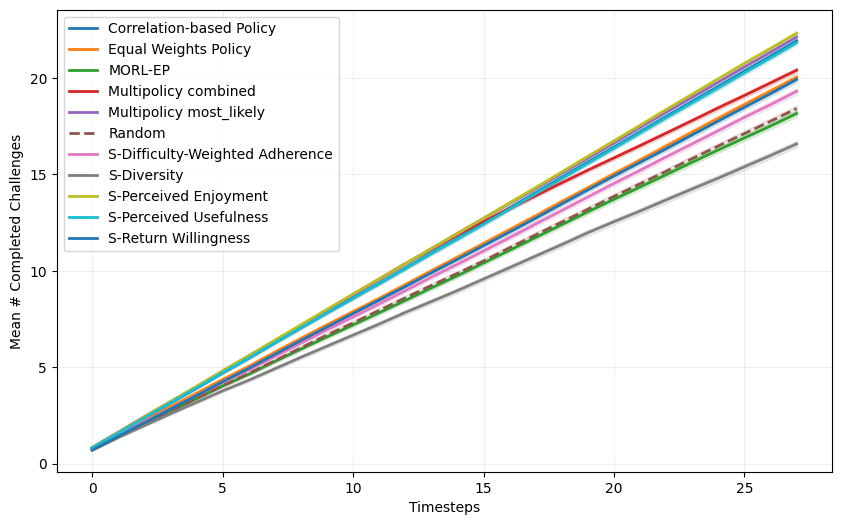

In [27]:
sim_utils.plot_simulation(combined_df, 'num_completed')

#### Inspect number of users per state

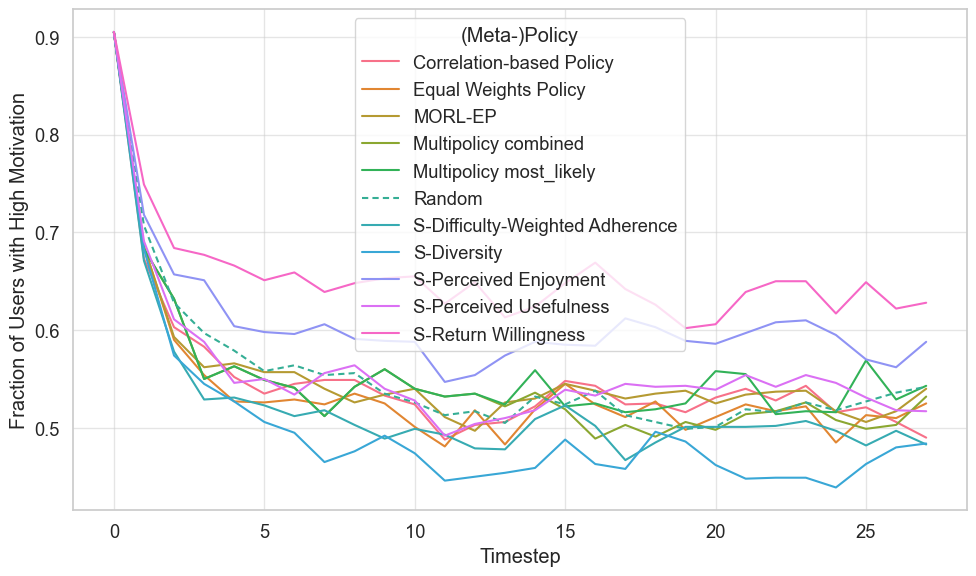

In [28]:
sim_utils.plot_state_trajectory(combined_df, threshold=1)

#### Inspect diversity

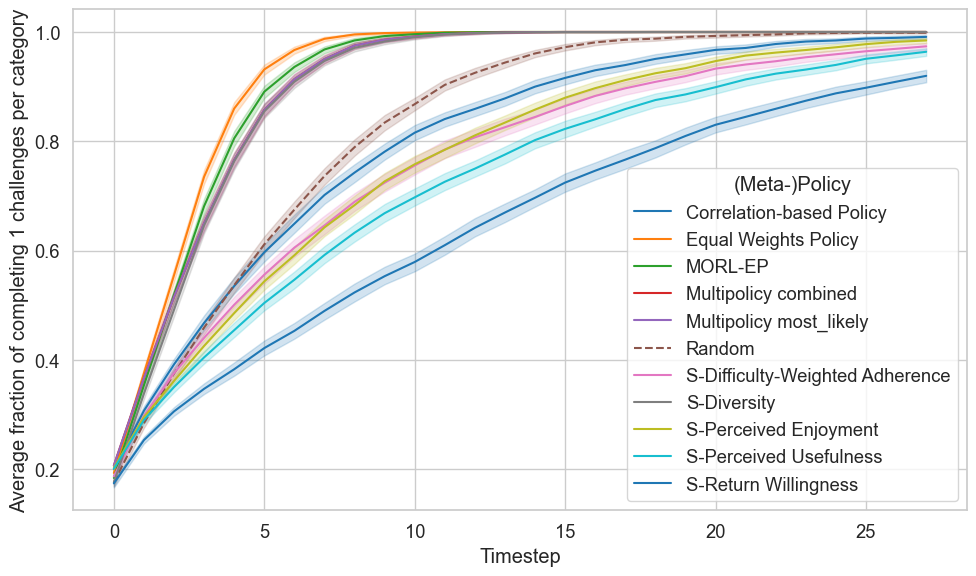

In [29]:
sim_utils.plot_fraction_completed(combined_df, 1)

#### Analyze dropout / retention

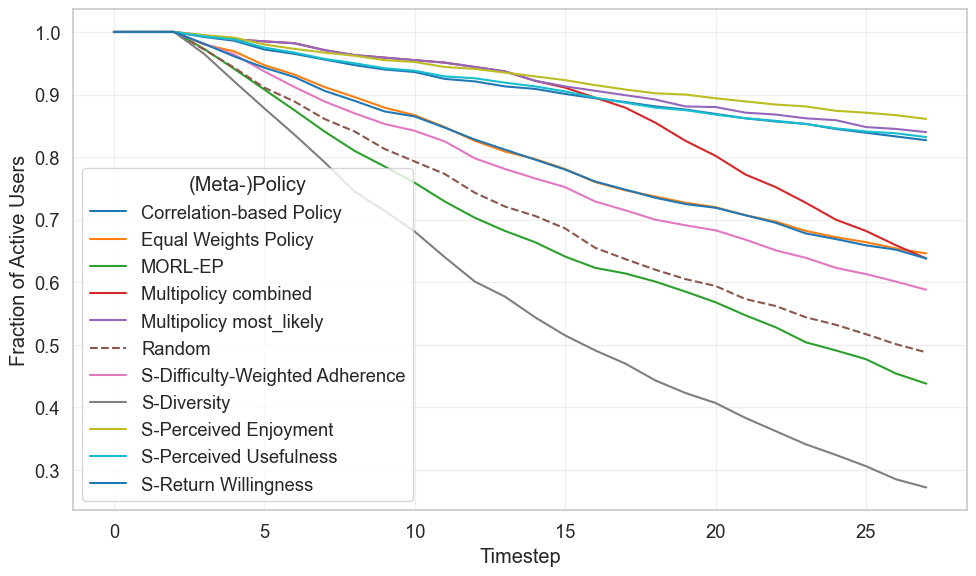

In [30]:
sim_utils.plot_dropout(combined_df)

### Simulate multiple simulations to get more reliable estimates of dropout and motivation trajectory

In [31]:
num_runs = 100
num_users_per_run = 500

